# Sepsis-3 in MIMIC-III

This is the primary notebook for analyzing sepsis-3 in the MIMIC-III database. Before running this notebook, you'll need the `sepsis3-df.csv` file in the local directory: either by downloading it directly from PhysioNet or running the SQL scripts enclosed on the MIMIC-III database. See `sepsis-3-get-data.ipynb` for more detail.

In [1]:

from __future__ import print_function

# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import subprocess
import tableone
from collections import OrderedDict
from statsmodels.formula.api import logit
from IPython.display import display, HTML # used to print out pretty pandas dataframes

from sepsis_utils import sepsis_utils as su
from sepsis_utils import roc_utils as ru

# used to calculate AUROC/accuracy
from sklearn import metrics

# default colours for prettier plots
col = [[0.9047, 0.1918, 0.1988],
    [0.2941, 0.5447, 0.7494],
    [0.3718, 0.7176, 0.3612],
    [1.0000, 0.5482, 0.1000],
    [0.4550, 0.4946, 0.4722],
    [0.6859, 0.4035, 0.2412],
    [0.9718, 0.5553, 0.7741],
    [0.5313, 0.3359, 0.6523]];
marker = ['v','o','d','^','s','o','+']
ls = ['-','-','-','-','-','s','--','--']

import colorsys
def gg_color_hue(n):
    hues = np.linspace(15, 375, n)
    hsv_tuples = [(x*1.0/360.0, 0.5, 0.8) for x in hues]
    rgb_tuples = map(lambda x: colorsys.hsv_to_rgb(*x), hsv_tuples)
    return rgb_tuples

# path used for data - can be a relative path to the current folder
data_path = 'data'

%matplotlib inline
plt.style.use('ggplot')

font = {'family' : 'DejaVu Sans',
        'size'   : 20}

matplotlib.rc('font', **font)

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
df = pd.read_csv(os.path.join(data_path,'sepsis3-df.csv'))

# add the composite outcome
df['composite_outcome'] = ( (df['hospital_expire_flag']==1) | (df['icu_los']>=3) ).astype(int)

labels = OrderedDict([['suspicion_poe', 'BC + ABX (Prescribed)']])

# add some other useful variables
df['blood culture'] = (~df['blood_culture_time'].isnull())
df['suspicion_poe'] = (~df['suspected_infection_time_poe_days'].isnull())

df['abx_poe'] = (~df['antibiotic_time_poe'].isnull())

df['sepsis-3'] = ((df['suspicion_poe']==1) & (df['sofa']>=2)).astype(int)
df['sofa>=2'] = (df['sofa']>=2).astype(int)


for c in ['intime','outtime',
          'suspected_infection_time_mv','suspected_infection_time',
          'suspected_infection_time_poe', 'blood_culture_time']:
    if c in df.columns:
        if df[c].dtype == 'object':
            df[c] = pd.to_datetime(df[c])

# list of the sepsis definitions
sepsis_list = ['sepsis_angus','sepsis_martin', 'sepsis_explicit',
               'sepsis_cdc','sepsis_nqf',
               'sepsis-3']

# Results for Abstract

In [3]:
# see get-data for the exclusions
print('{:5g} patients.'.format(df.shape[0]))

print('{:5g} ({:2.0f}%) suspected of infection.'.format(
        df['suspicion_poe'].sum(), df['suspicion_poe'].sum()*100.0/df.shape[0]))

print('{:5g} ({:2.2f}%) have SOFA >= 2.'.format(
    df['sofa>=2'].sum(),100.0*df['sofa>=2'].mean()))

print('{:5g} ({:2.2f}%) have Sepsis-3 criteria (intersection of above two).'.format(
    df['sepsis-3'].sum(),100.0*df['sepsis-3'].mean()))

print('{:5g} ({:2.2f}%) have suspicion and SOFA < 2.'.format(
        ((df['sofa>=2']==0) & (df['suspicion_poe']==1)).sum(),
        ((df['sofa>=2']==0) & (df['suspicion_poe']==1)).sum()*100.0/df.shape[0]))

for c in sepsis_list:
    print('{:5g} ({:3.2f}%) - {}'.format(
        df[c].sum(), df[c].sum()*100.0/df.shape[0], c))

print('{:5g} ({:2.2f}%) have Sepsis-3 criteria but not Angus.'.format(
        ((df['sepsis_angus']==0) & (df['sepsis-3']==1)).sum(),
        ((df['sepsis_angus']==0) & (df['sepsis-3']==1)).sum()*100.0/df.shape[0]))


np.random.seed(21381)
# cronbach alpha for construct validity
calpha = su.cronbach_alpha_table(df, sepsis_list)

# remove "sepsis_" prefix from columns/indices
calpha.columns = [x.replace('sepsis_','') for x in calpha.columns]
calpha.index = [x.replace('sepsis_','') for x in calpha.index]

print('\n === Cronbach Alpha ===')
display(HTML(calpha.fillna('').to_html()))

11325 patients.
 7122 (63%) suspected of infection.
 8499 (75.05%) have SOFA >= 2.
 5784 (51.07%) have Sepsis-3 criteria (intersection of above two).
 1338 (11.81%) have suspicion and SOFA < 2.
 3250 (28.70%) - sepsis_angus
 1676 (14.80%) - sepsis_martin
 1031 (9.10%) - sepsis_explicit
 3711 (32.77%) - sepsis_cdc
 1255 (11.08%) - sepsis_nqf
 5784 (51.07%) - sepsis-3
 2978 (26.30%) have Sepsis-3 criteria but not Angus.

 === Cronbach Alpha ===


,angus,martin,explicit,cdc,nqf,sepsis-3
angus,,0.70 [0.68-0.71],0.62 [0.61-0.64],0.62 [0.60-0.63],0.64 [0.62-0.65],0.62 [0.60-0.63]
martin,,,0.85 [0.84-0.86],0.53 [0.51-0.55],0.91 [0.90-0.92],0.48 [0.47-0.50]
explicit,,,,0.49 [0.47-0.51],0.90 [0.89-0.90],0.39 [0.38-0.40]
cdc,,,,,0.52 [0.50-0.54],0.74 [0.73-0.75]
nqf,,,,,,0.43 [0.42-0.45]


# Results section

We now print out the results in the same order as they are in the paper.

# Demographics

In [4]:
# Call the print_demographics subfunction, which prints out a reasonably formatted table
su.print_demographics(df)

print('\nAlive vs. dead')
su.print_demographics(df, idx=(df.hospital_expire_flag.values==1))

print('')

print('{:5g} have SIRS >= 2 ({:2.2f}%) on admission.'.format(
    (df.sirs.values >= 2).sum(),100.0*(df.sirs.values >= 2).mean()))

print('{:5g} have qSOFA >= 2 ({:2.2f}%) on admission.'.format(
    (df.qsofa.values >= 2).sum(),100.0*(df.qsofa.values >= 2).mean()))

print('{:5g} have SOFA >= 2 ({:2.2f}%).'.format(
    (df.sofa.values >= 2).sum(),100.0*(df.sofa.values >= 2).mean()))

print('{:5g} have LODS >= 2 ({:2.2f}%).'.format(
    (df.lods.values >= 2).sum(),100.0*(df.lods.values >= 2).mean()))

N                   	11325
age                 	64.5 [50.9, 78.6]
gender              	6236 (55.1%)
bmi                 	28.6 +- 8.4
Race                	
White               	8130 (71.8%)
Black               	1078 (9.5%)
Hispanic            	 450 (9.5%)
elixhauser_hospital 	1.0 [-1.0, 6.0]
qsofa               	2.0 [1.0, 2.0]
sirs                	3.0 [2.0, 3.0]
sofa                	3.0 [2.0, 5.0]
mlods               
lactate_max         
vent                	4004 (35.4%)
icu_los             	1.9 [1.1, 3.5]
hosp_los            	5.4 [3.0, 9.4]
thirtyday_expire_flag	1580 (14.0%)
hospital_expire_flag	1256 (11.1%)

Alive vs. dead
N                   	10069     	1256     	     
age                 	63.3 [49.8, 77.5]	74.9 [61.8, 83.7]	< 0.001
gender              	5569 (55.3%)	 667 (53.1%)	0.147
bmi                 	28.7 +- 8.2	28.1 +- 10.2	0.219
ethnicity           	          	          	< 0.001
  black             	1004 (10.0%)	  74 (5.9%)	     
  hispanic          	 417 (4.1%)	  33 (2.6%)	 

/tmp/ipykernel_33220/3451961550.py:2: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  su.print_demographics(df)
/tmp/ipykernel_33220/3451961550.py:2: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  su.print_demographics(df)
/tmp/ipykernel_33220/3451961550.py:2: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  su.print_demographics(df)
/tmp/ipykernel_33220/3451961550.py:2: De

## Frequency of primary/secondary outcomes for each score

First print a table, then plot the figure.

In [5]:
# list probability of outcome for each score
scores = ['suspicion_poe','sofa>=2',
          'sepsis-3',
          'sepsis_angus','sepsis_martin','sepsis_explicit',
          'sepsis_cdc','sepsis_nqf']

scores_dict = {
    'suspicion_poe': 'Suspected infection',
    'sofa>=2': 'SOFA >= 2',
    'sepsis-3': 'Sepsis-3',
    'sepsis_angus': 'Angus et al. criteria',
    'sepsis_martin': 'Martin et al. criteria',
    'sepsis_explicit': 'Explicit',
    'sepsis_cdc': 'CDC',
    'sepsis_nqf': 'CMS'
}
target_header = "hospital_expire_flag"
idx = df[target_header]==1

print()
print('=== {} ==='.format(target_header))
print()
print('{:15s}\t{:8s}\t{:5s}\t{:5s}'.format(
    'Criteria','N','p(death|c)', 'p(death|~c)'))
for c in scores:
    print('{:15s}\t{:4d}, {:2.1f}%\t{:2.1f}%\t\t{:2.1f}%'.format(
            c,
            np.sum( df[c]==1 ),
            np.sum( df[c]==1 )*100.0/df.shape[0],
            np.sum( (df[c]==1)&idx )*100.0 / np.sum( df[c]==1 ),
            np.sum( (df[c]!=1)&idx )*100.0 / np.sum( df[c]!=1 )
        ))
    
target_header = "composite_outcome"
idx = df[target_header]==1

print()
print('=== {} ==='.format(target_header))
print()

print('{:15s}\t{:8s}\t{:5s}\t{:5s}'.format(
    'Criteria','N','p(death|c)', 'p(death|~c)'))
for c in scores:
    print('{:15s}\t{:4d}, {:2.1f}%\t{:2.1f}%\t\t{:2.1f}%'.format(
            c,
            np.sum( df[c]==1 ),
            np.sum( df[c]==1 )*100.0/df.shape[0],
            np.sum( (df[c]==1)&idx )*100.0 / np.sum( df[c]==1 ),
            np.sum( (df[c]!=1)&idx )*100.0 / np.sum( df[c]!=1 )
        ))


=== hospital_expire_flag ===

Criteria       	N       	p(death|c)	p(death|~c)
suspicion_poe  	7122, 62.9%	12.6%		8.6%
sofa>=2        	8499, 75.0%	13.5%		3.8%
sepsis-3       	5784, 51.1%	14.6%		7.5%
sepsis_angus   	3250, 28.7%	18.2%		8.2%
sepsis_martin  	1676, 14.8%	23.1%		9.0%
sepsis_explicit	1031, 9.1%	30.4%		9.2%
sepsis_cdc     	3711, 32.8%	19.0%		7.2%
sepsis_nqf     	1255, 11.1%	27.5%		9.0%

=== composite_outcome ===

Criteria       	N       	p(death|c)	p(death|~c)
suspicion_poe  	7122, 62.9%	45.4%		19.5%
sofa>=2        	8499, 75.0%	41.3%		19.2%
sepsis-3       	5784, 51.1%	49.4%		21.7%
sepsis_angus   	3250, 28.7%	61.3%		25.5%
sepsis_martin  	1676, 14.8%	60.3%		31.6%
sepsis_explicit	1031, 9.1%	70.5%		32.3%
sepsis_cdc     	3711, 32.8%	61.1%		23.5%
sepsis_nqf     	1255, 11.1%	64.9%		32.2%


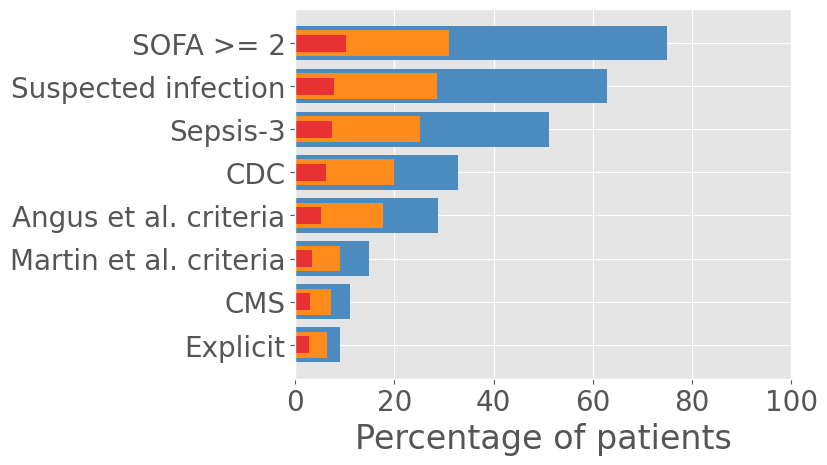


Criteria       	N       	p(death|c)	p(death|~c)	p(comp|c)	p(comp|~c)
sofa>=2        	8499, 75.0%	13.5%		3.8%		41.3%		19.2%
suspicion_poe  	7122, 62.9%	12.6%		8.6%		45.4%		19.5%
sepsis-3       	5784, 51.1%	14.6%		7.5%		49.4%		21.7%
sepsis_cdc     	3711, 32.8%	19.0%		7.2%		61.1%		23.5%
sepsis_angus   	3250, 28.7%	18.2%		8.2%		61.3%		25.5%
sepsis_martin  	1676, 14.8%	23.1%		9.0%		60.3%		31.6%
sepsis_nqf     	1255, 11.1%	27.5%		9.0%		64.9%		32.2%
sepsis_explicit	1031, 9.1%	30.4%		9.2%		70.5%		32.3%


In [6]:
# create a figure of the above frequencies
scores = ['suspicion_poe','sofa>=2',
          'sepsis-3',
          'sepsis_angus','sepsis_martin','sepsis_explicit',
          'sepsis_cdc','sepsis_nqf']

scores_dict = {
    'suspicion_poe': 'Suspected infection',
    'sofa>=2': 'SOFA >= 2',
    'sepsis-3': 'Sepsis-3',
    'sepsis_angus': 'Angus et al. criteria',
    'sepsis_martin': 'Martin et al. criteria',
    'sepsis_explicit': 'Explicit',
    'sepsis_cdc': 'CDC',
    'sepsis_nqf': 'CMS'
}

idx = df['hospital_expire_flag']==1
idxComp = df['composite_outcome']==1

score_plot = np.zeros( [len(scores), 3] )
for i, c in enumerate(scores):
    # proportion of patients
    score_plot[i, 0] = np.sum( df[c]==1 )*100.0/df.shape[0]
    
    # with mort
    score_plot[i, 1] = np.sum( (df[c]==1)&idx )*100.0 / np.sum( df[c]==1 )
    # with comp
    score_plot[i, 2] = np.sum( (df[c]==1)&idxComp )*100.0 / np.sum( df[c]==1 )
    
S = len(scores)

idxSort = np.argsort(score_plot[:,0])
plt.figure()
plt.barh( range(S), score_plot[idxSort,0], color=col[1], align='center')
plt.barh( range(S), score_plot[idxSort,0]*score_plot[idxSort,2]/100.0, color=col[3], align='center', height=0.6)
plt.barh( range(S), score_plot[idxSort,0]*score_plot[idxSort,1]/100.0, color=col[0], align='center', height=0.4)

plt.yticks(range(S), [scores_dict[scores[x]] for x in idxSort])
plt.xlabel('Percentage of patients')
plt.xlim([0,100])
plt.show()

print('')
print('{:15s}\t{:8s}\t{:5s}\t{:5s}\t{:5s}\t{:5s}'.format(
    'Criteria','N','p(death|c)', 'p(death|~c)', 'p(comp|c)', 'p(comp|~c)'))
for i in idxSort[-1::-1]:
    c=scores[i]
    print('{:15s}\t{:4d}, {:2.1f}%\t{:2.1f}%\t\t{:2.1f}%\t\t{:2.1f}%\t\t{:2.1f}%'.format(
            c,
            np.sum( df[c]==1 ),
            np.sum( df[c]==1 )*100.0/df.shape[0],
            np.sum( (df[c]==1)&idx )*100.0 / np.sum( df[c]==1 ),
            np.sum( (df[c]!=1)&idx )*100.0 / np.sum( df[c]!=1 ),
            np.sum( (df[c]==1)&idxComp )*100.0 / np.sum( df[c]==1 ),
            np.sum( (df[c]!=1)&idxComp )*100.0 / np.sum( df[c]!=1 )
        ))
    

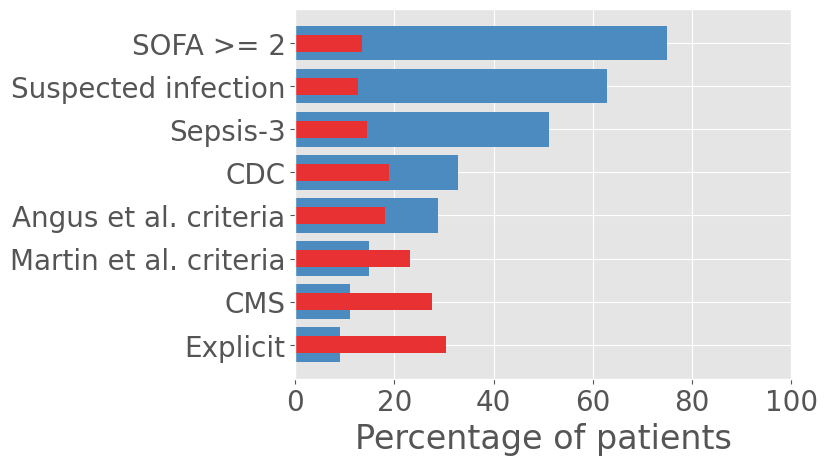

In [7]:
# print the frequencies
# list probability of outcome for each score
scores = ['suspicion_poe','sofa>=2',
          'sepsis-3',
          'sepsis_angus','sepsis_martin','sepsis_explicit',
          'sepsis_cdc','sepsis_nqf']

scores_dict = {
    'suspicion_poe': 'Suspected infection',
    'sofa>=2': 'SOFA >= 2',
    'sepsis-3': 'Sepsis-3',
    'sepsis_angus': 'Angus et al. criteria',
    'sepsis_martin': 'Martin et al. criteria',
    'sepsis_explicit': 'Explicit',
    'sepsis_cdc': 'CDC',
    'sepsis_nqf': 'CMS'
}

idx = df['hospital_expire_flag']==1
idxComp = df['composite_outcome']==1

score_plot = np.zeros( [len(scores), 3] )
for i, c in enumerate(scores):
    # proportion of patients
    score_plot[i, 0] = np.sum( df[c]==1 )*100.0/df.shape[0]
    
    # with mort
    score_plot[i, 1] = np.sum((df[c]==1)&idx)*100.0 / np.sum( df[c]==1 )
    # with comp
    score_plot[i, 2] = np.sum( (df[c]==1)&idxComp )*100.0 / np.sum( df[c]==1 )
    
S = len(scores)

idxSort = np.argsort(score_plot[:,0])

plt.figure()
plt.barh( range(S), score_plot[idxSort,0], color=col[1], align='center', label='Patients')
#plt.barh( range(S), score_plot[idxSort,2], color=col[3], align='center', height=0.6)
plt.barh( range(S), score_plot[idxSort,1], color=col[0], align='center', height=0.4, label='Patients who died')
#ax2.set_xlim(ax2.get_xlim()[::-1])

#plt.plot( score_plot[idxSort,1], range(S), color=col[0], marker='o', markersize=10)
#ax1.barh( range(S), score_plot[idxSort,0]*score_plot[idxSort,2]/100.0, color=col[3], align='center', height=0.6)
#
#ax2 = ax1.twiny()
#ax2.barh( range(S), (score_plot[idxSort,0]*score_plot[idxSort,1]/100.0), color=col[0], align='center', height=0.4)
#ax2.set_xlim(ax2.get_xlim()[::-1])
#ax2.plot(range(S), score_plot[idxSort,0]*score_plot[idxSort,1]/100.0, color=col[0] )

plt.yticks(range(S), [scores_dict[scores[x]] for x in idxSort])
plt.xlabel('Percentage of patients')
#plt.legend(loc='lower right')
plt.xlim([0,100])
plt.show()

In [8]:
# create a dataframe for these probabilities
df_outcome = pd.DataFrame(columns=['Criteria','N','p(death|c)', 'p(death|~c)', 'p(comp|c)', 'p(comp|~c)'], dtype=float)
# same print but to csv
for i in idxSort[-1::-1]:
    c=scores[i]
    df_outcome.loc[scores_dict[c], :] = [np.sum( df[c]==1 ),
            np.sum( df[c]==1 )*100.0/df.shape[0],
            np.sum( (df[c]==1)&idx )*100.0 / np.sum( df[c]==1 ),
            np.sum( (df[c]!=1)&idx )*100.0 / np.sum( df[c]!=1 ),
            np.sum( (df[c]==1)&idxComp )*100.0 / np.sum( df[c]==1 ),
            np.sum( (df[c]!=1)&idxComp )*100.0 / np.sum( df[c]!=1 )]
    #print('{},{:4d} {:2.1f}%,{:2.1f}%,{:2.1f}%,{:2.1f}%,{:2.1f}%'.format(
    #    ))
    
# display .. maximum of 2 decimal places
display(HTML(df_outcome.round(decimals=2).to_html()))

,Criteria,N,p(death|c),p(death|~c),p(comp|c),p(comp|~c)
SOFA >= 2,8499.0,75.05,13.52,3.79,41.32,19.25
Suspected infection,7122.0,62.89,12.57,8.59,45.42,19.53
Sepsis-3,5784.0,51.07,14.56,7.47,49.38,21.66
CDC,3711.0,32.77,18.97,7.25,61.06,23.51
Angus et al. criteria,3250.0,28.70,18.15,8.25,61.32,25.55
Martin et al. criteria,1676.0,14.80,23.09,9.01,60.32,31.56
CMS,1255.0,11.08,27.49,9.05,64.94,32.18
Explicit,1031.0,9.10,30.36,9.16,70.51,32.34


In [9]:
# note: we need to subselect to the cohort suspected of infection in order to compare AUROCs to previous literature
idx = df['suspicion_poe'].values == 1
pred_header = 'sofa'

print('Comparison to past literature performance.')
#print'{}'


df_past_literature = pd.DataFrame(columns=['hospital_expire_flag','composite_outcome'])
df_past_literature.loc['Seymour et al., 2016',:] = ['0.74 [0.73 - 0.76]', '~0.74 (inferred from eFigure 6)']
df_past_literature.loc['Raith et al., 2017',:] = ['0.753 [0.750 - 0.757]', '0.736 [0.733 - 0.739]']
np.random.seed(7891)
# AUROC of sofa for in-hospital mortality
target_header = 'hospital_expire_flag'
auc_hosp, ci_hosp = ru.calc_auc(df.loc[idx, pred_header].values, df.loc[idx, target_header].values, with_ci=True)
target_header = 'composite_outcome'
auc_comp, ci_comp = ru.calc_auc(df.loc[idx, pred_header].values, df.loc[idx, target_header].values, with_ci=True)

df_past_literature.loc['Our results', :] = ['{:0.3f} [{:0.3f} - {:0.3f}]'.format(auc_hosp, ci_hosp[0], ci_hosp[1]),
                                           '{:0.3f} [{:0.3f} - {:0.3f}]'.format(auc_comp, ci_comp[0], ci_comp[1])]


display(HTML(df_past_literature.to_html()))

Comparison to past literature performance.


,hospital_expire_flag,composite_outcome
"Seymour et al., 2016",0.74 [0.73 - 0.76],~0.74 (inferred from eFigure 6)
"Raith et al., 2017",0.753 [0.750 - 0.757],0.736 [0.733 - 0.739]
Our results,0.743 [0.725 - 0.761],0.694 [0.682 - 0.706]


In the above, it is worth noting that:

* The results of Seymour et al. are for a model incorporating age, gender, race, and comorbid status
* The results of Raith et al. are for the uncalibrated univariable score ("crude")

In [10]:
# operating point statistics on sofa >= 2
yhat_dict = OrderedDict([['SOFA>=2', df['sofa>=2']]
                        ])
stats_all = su.get_op_stats(yhat_dict, df[target_header].values)
su.print_op_stats(stats_all)

Metric

     	SOFA>=2 
TN   	 2282
FP   	 4987
FN   	  544
TP   	 3512
Sens 	87 [86, 88]
Spec 	31 [30, 32]
PPV  	41 [40, 42]
NPV  	81 [79, 82]
F1   	 55.95   
NTP  	 31.01   
NFP  	 44.04   


# Sepsis

Create the sepsis-3 criteria: SOFA >= 2 and suspicion of infection.

In [11]:
print('{:5g} ({:3.2f}%)  first ICU stay for adults.'.format(
        df['icustay_id'].count(), 100))
print('{:5g} ({:3.2f}%)  suspected of infection'.format(
        np.sum(df['suspicion_poe']),
        np.sum(df['suspicion_poe'])*100.0/df.shape[0]))
print('{:5g} ({:3.2f}%)  with a positive blood culture'.format(
    df['blood_culture_positive'].sum(), df['blood_culture_positive'].sum()*100.0/df.shape[0]))

print()
for i, c in enumerate(labels):
    print('{:5g} ({:3.2f}%) - {}'.format(
        df[c].sum(), df[c].sum()*100.0/df.shape[0], c))

11325 (100.00%)  first ICU stay for adults.
 7122 (62.89%)  suspected of infection
 2679 (23.66%)  with a positive blood culture

 7122 (62.89%) - suspicion_poe


## Venn diagrams of Sepsis-3 against other criteria

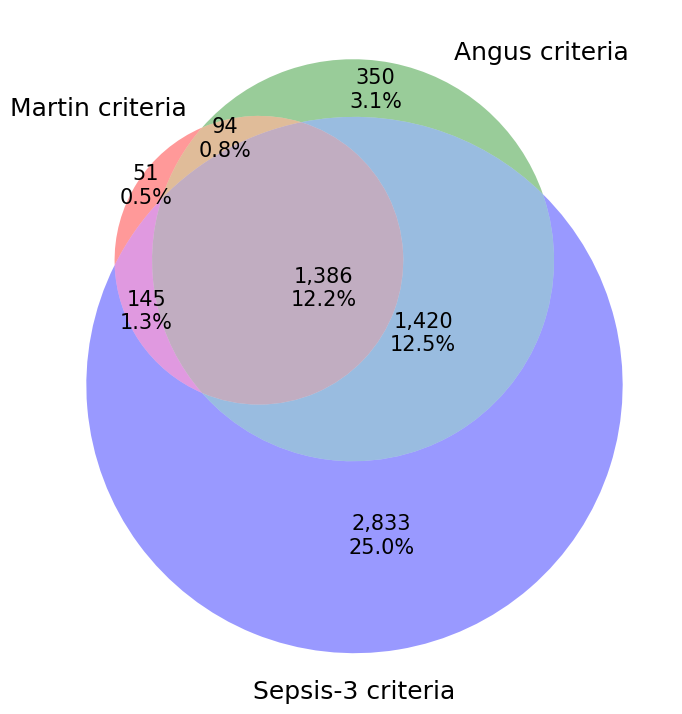

1386 patients (12.2%) satisfied all criteria.
5046 patients (44.6%) satisfied no criteria.
13.1% (1480) - sepsis_angus & sepsis_martin
13.5% (1531) - sepsis-3 & sepsis_martin
24.8% (2806) - sepsis-3 & sepsis_angus


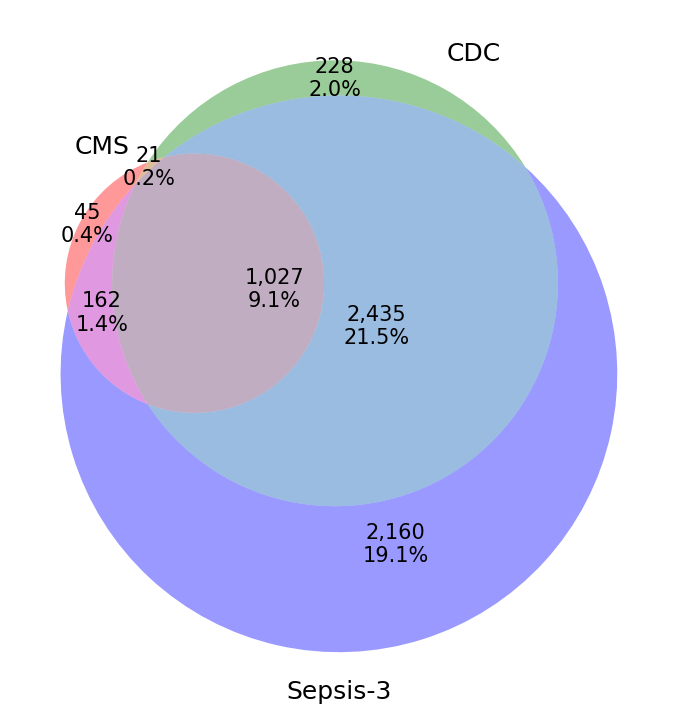

1027 patients (9.1%) satisfied all criteria.
5247 patients (46.3%) satisfied no criteria.
9.3% (1048) - sepsis_cdc & sepsis_nqf
10.5% (1189) - sepsis-3 & sepsis_nqf
30.6% (3462) - sepsis-3 & sepsis_cdc


In [12]:
# define labels here
# first label = red (top left)
# second label = green (top right)
# third label = blue (bottom)

venn_labels = OrderedDict([
        ['sepsis_martin', 'Martin criteria'],
        ['sepsis_angus', 'Angus criteria'],
        ['sepsis-3', 'Sepsis-3 criteria']
    ])
su.create_venn_diagram(df, venn_labels)

venn_labels = OrderedDict([
        ['sepsis_nqf', 'CMS'],
        ['sepsis_cdc', 'CDC'],
        ['sepsis-3', 'Sepsis-3']
    ])
su.create_venn_diagram(df, venn_labels)

# Mortality rates for each group

In [13]:
target_header = "hospital_expire_flag"
idx = df[target_header]==1

# make a confusion matrix with multiple scores in each square
scores = ['sepsis_angus','sepsis_martin','sepsis_explicit','suspicion_poe','sepsis-3','sofa>=2']

print('{:15s} {:15s} {:15s}'.format('0','dead','alive','outcome %'))

for c in scores:
    print('{:15s} {:4d} {:1.1f}%\t{:5d} {:1.1f}%  {:1.1f}%'.format(
            c,
            np.sum( (df[c]!=1)&idx ),  np.sum( (df[c]!=1)&idx )*100.0/df.shape[0],
            np.sum( (df[c]!=1)&~idx ), np.sum( (df[c]!=1)&~idx )*100.0/df.shape[0],
            np.sum( (df[c]!=1)&idx )*100.0/np.sum(df[c]!=1)
        ))
print()
print('1')
for c in scores:
    print('{:15s} {:4d} {:1.1f}%\t{:5d} {:1.1f}%  {:1.1f}%'.format(
            c,
            np.sum( (df[c]==1)&idx ),  np.sum( (df[c]==1)&idx )*100.0/df.shape[0],
            np.sum( (df[c]==1)&~idx ), np.sum( (df[c]==1)&~idx )*100.0/df.shape[0],
            np.sum( (df[c]==1)&idx )*100.0/np.sum(df[c]==1)
        ))

0               dead            alive          
sepsis_angus     666 5.9%	 7409 65.4%  8.2%
sepsis_martin    869 7.7%	 8780 77.5%  9.0%
sepsis_explicit  943 8.3%	 9351 82.6%  9.2%
suspicion_poe    361 3.2%	 3842 33.9%  8.6%
sepsis-3         414 3.7%	 5127 45.3%  7.5%
sofa>=2          107 0.9%	 2719 24.0%  3.8%

1
sepsis_angus     590 5.2%	 2660 23.5%  18.2%
sepsis_martin    387 3.4%	 1289 11.4%  23.1%
sepsis_explicit  313 2.8%	  718 6.3%  30.4%
suspicion_poe    895 7.9%	 6227 55.0%  12.6%
sepsis-3         842 7.4%	 4942 43.6%  14.6%
sofa>=2         1149 10.1%	 7350 64.9%  13.5%


# Composite outcome for each group

In [14]:
target_header = "composite_outcome"
idx = (df['hospital_expire_flag']==1) | (df['icu_los']>=3)

# make a confusion matrix with multiple scores in each square
scores = ['sepsis_angus','sepsis_martin','sepsis_explicit','suspicion_poe','sepsis-3','sofa>=2']


print('{:15s} {:12s} {:15s}'.format('0','dead/hi-LOS','alive/lo-LOS','outcome %'))

for c in scores:
    print('{:15s} {:4d} {:1.1f}%   {:5d} {:1.1f}%  {:1.1f}%'.format(
            c,
            np.sum( (df[c]!=1)&idx ),  np.sum( (df[c]!=1)&idx )*100.0/df.shape[0],
            np.sum( (df[c]!=1)&~idx ), np.sum( (df[c]!=1)&~idx )*100.0/df.shape[0],
            np.sum( (df[c]!=1)&idx )*100.0/np.sum(df[c]!=1)
        ))
print()
print('1')
for c in scores:
    print('{:15s} {:4d} {:1.1f}%   {:5d} {:1.1f}%  {:1.1f}%'.format(
            c,
            np.sum( (df[c]==1)&idx ),  np.sum( (df[c]==1)&idx )*100.0/df.shape[0],
            np.sum( (df[c]==1)&~idx ), np.sum( (df[c]==1)&~idx )*100.0/df.shape[0],
            np.sum( (df[c]==1)&idx )*100.0/np.sum(df[c]==1)
        ))

0               dead/hi-LOS  alive/lo-LOS   
sepsis_angus    2063 18.2%    6012 53.1%  25.5%
sepsis_martin   3045 26.9%    6604 58.3%  31.6%
sepsis_explicit 3329 29.4%    6965 61.5%  32.3%
suspicion_poe    821 7.2%    3382 29.9%  19.5%
sepsis-3        1200 10.6%    4341 38.3%  21.7%
sofa>=2          544 4.8%    2282 20.2%  19.2%

1
sepsis_angus    1993 17.6%    1257 11.1%  61.3%
sepsis_martin   1011 8.9%     665 5.9%  60.3%
sepsis_explicit  727 6.4%     304 2.7%  70.5%
suspicion_poe   3235 28.6%    3887 34.3%  45.4%
sepsis-3        2856 25.2%    2928 25.9%  49.4%
sofa>=2         3512 31.0%    4987 44.0%  41.3%


# Mortality: operating point statistics

In [15]:
target_header = "hospital_expire_flag"

# sepsis3 defined as qSOFA >= 2 and SOFA >= 2
yhat_dict = OrderedDict([['SOFA', df.sofa.values >= 2],
                        ['SIRS', df.sirs.values >= 2],
                        ['qSOFA', df.qsofa.values >= 2]])

stats_all = su.get_op_stats(yhat_dict, df[target_header].values)

su.print_op_stats(stats_all)

Metric

     	SOFA    	SIRS    	qSOFA   
TN   	 2719		 1492		 3883
FP   	 7350		 8577		 6186
FN   	  107		   64		  256
TP   	 1149		 1192		 1000
Sens 	91 [90, 93]	95 [94, 96]	80 [77, 82]
Spec 	27 [26, 28]	15 [14, 16]	39 [38, 40]
PPV  	14 [13, 14]	12 [12, 13]	14 [13, 15]
NPV  	96 [95, 97]	96 [95, 97]	94 [93, 95]
F1   	 23.56   	 21.62   	 23.69   
NTP  	 10.15   	 10.53   	 8.83   
NFP  	 64.90   	 75.74   	 54.62   


# Composite outcome: operating point statistics

In [16]:
target_header = "composite_outcome"

# sepsis3 defined as qSOFA >= 2 and SOFA >= 2
yhat_dict = OrderedDict([['SOFA', df.sofa.values >= 2],
                        ['SIRS', df.sirs.values >= 2],
                        ['qSOFA', df.qsofa.values >= 2]])

stats_all = su.get_op_stats(yhat_dict, df[target_header].values)

su.print_op_stats(stats_all)

Metric

     	SOFA    	SIRS    	qSOFA   
TN   	 2282		 1272		 3117
FP   	 4987		 5997		 4152
FN   	  544		  284		 1022
TP   	 3512		 3772		 3034
Sens 	87 [86, 88]	93 [92, 94]	75 [73, 76]
Spec 	31 [30, 32]	17 [17, 18]	43 [42, 44]
PPV  	41 [40, 42]	39 [38, 40]	42 [41, 43]
NPV  	81 [79, 82]	82 [80, 84]	75 [74, 77]
F1   	 55.95   	 54.57   	 53.98   
NTP  	 31.01   	 33.31   	 26.79   
NFP  	 44.04   	 52.95   	 36.66   


# Severity of illness stats

In [17]:
print('{:5g} ({:3.1f}%) first ICU stay for adults.'.format(
        df['icustay_id'].count(), 100))
for c in ['sirs','qsofa','sofa','sepsis-3',
          'sepsis_angus','sepsis_martin','sepsis_explicit']:
    if df[c].max() == 1:
        print('{:5g} ({:3.1f}%)  with {}'.format(
                (df[c]==1).sum(),
                (df[c]==1).sum()*100.0/df.shape[0], c))
    else:
        print('{:5g} ({:3.1f}%)  with {} >= 2'.format(
                (df[c]>=2).sum(),
                (df[c]>=2).sum()*100.0/df.shape[0], c))

11325 (100.0%) first ICU stay for adults.
 9769 (86.3%)  with sirs >= 2
 7186 (63.5%)  with qsofa >= 2
 8499 (75.0%)  with sofa >= 2
 5784 (51.1%)  with sepsis-3
 3250 (28.7%)  with sepsis_angus
 1676 (14.8%)  with sepsis_martin
 1031 (9.1%)  with sepsis_explicit
